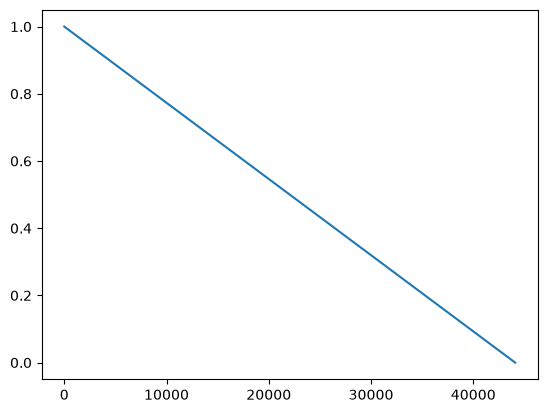

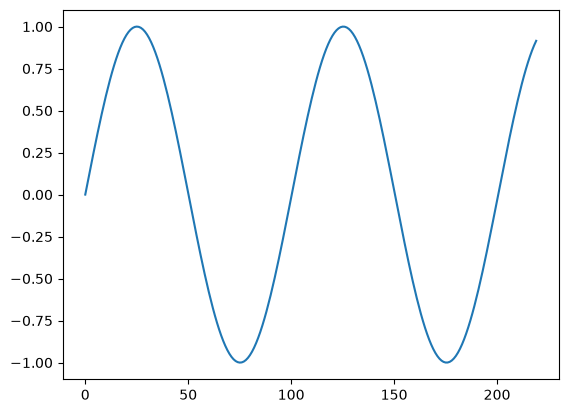

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# en mode notebook, ça peut être utile de choisir un mode interactif
# comme par exemple celui-ci
# par contre ça nécessite de faire un `pip install ipympl`
# %matplotlib ipympl
# pour jouer les sons qu'on va produire

from IPython.display import Audio,display
from scipy.io import wavfile
RATE = 44_100
LA = 440
DO = 523.25
pi=3.14
"""1.Pour une durée de 1 seconde il faut 44100 échantillons fois 1 seconde.
2.L'équation mathématique de la position est : f(t) =$cos(2pi phi t)$"""
"""Synthèse d'un son pur"""
t=np.linspace(0,1,RATE)
f=np.sin(2 *pi *LA *t)
plt.plot(f[:220])
display(Audio(f,rate=RATE)) #On montre un LA de 0.5ms et on le fait écouter pendant une seconde




In [ ]:
def display_signal(signal, rate=RATE,title="Signal",width=1):#fonction pour montrer un signal
    plt.plot(signal)
    display(Audio(signal,rate=RATE)) 

def  sine(freq, duration=1, amplitude=1.):
    #fonction pour fabriquer une sinusoïde
    t=np.linspace(0,duration,RATE) #Cette commande fabrique toujours les données de temps
    f=amplitude*np.sin(2*pi*freq*t)#Et f désigne encore le signal construit à partir des données
    return f 

def sine_linear(freq1, freq2, duration):
    #fonction pour fabriquer un glissando
    t=np.linspace(0, duration,RATE)
    freqq=(t*(freq2-freq1)/duration+freq1) #freqq est ici la freqq glissante entre freq1 et freq2
    f=np.sin(2*pi*f*t)
    return f

display_signal(sine_linear(LA,DO,1))

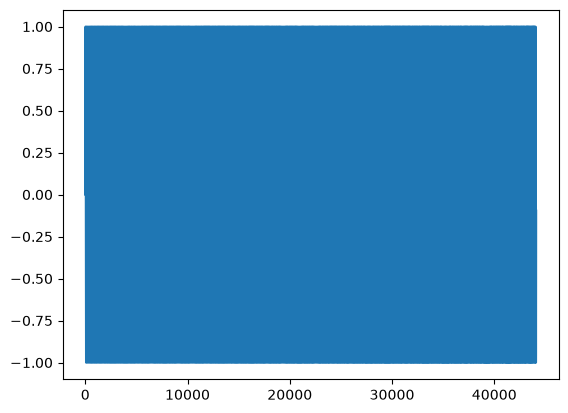

In [ ]:
"""Gestion du volume et de la dynamique"""

#Pour modifier l'amplitude de la sinusoïde il suffit de multiplier le sinus par un terme d'amplitude changeant selon la période.
#C'est-à-dire un autre tableau numpy de valeurs d'amplitude à donner pour chaque instant.

def crescendo_sine(freq, duration,increase=True):
    #fabrication d'un crescendo
    t=np.linspace(0, duration,RATE)
    if increase :
        amp=np.linspace(0,1, RATE) #Amplitude linéaire croissante passant de 0 à 1.
    else :
        amp=1-np.linspace(0,1,RATE) #Amplitude linéaire décroissante passant de 1 à 0.
    f=amp*np.sin(2*pi*freq*t)
    return f
#Pour un crescendo plus général on peut faire ceci :
 def crescendo_general(signal, increase=True):
    if increase :
        amp=np.linspace(0,1, RATE) #Amplitude linéaire croissante passant de 0 à 1.
    else :
        amp=1-np.linspace(0,1,RATE) #Amplitude linéaire décroissante passant de 1 à 0.
    f=signal*amp
    return f
     

display_signal(crescendo_sine(LA,1))

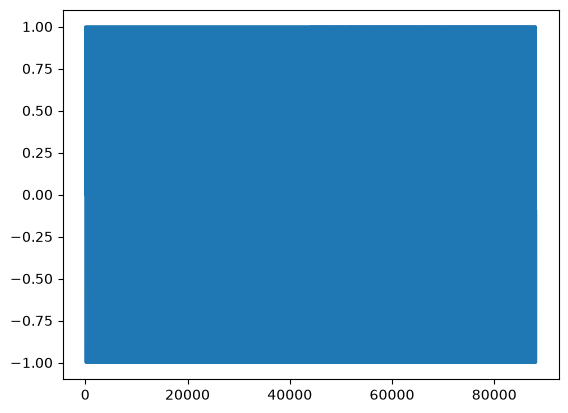

In [54]:
"""Concaténation de sons"""

def concatene(signal1,signal2):
    ff=np.concatenate((signal1,signal2))
    return ff

display_signal(concatene(sine(LA),sine(DO)))

In [ ]:
"""Formats de données audio"""
def float_to_int16(as_float):
    as_int16=np.int16(32767*as_float) #On utilise un transformateur de float à int16 après vectorisé, après s'être placé dans l'intervalle de int16
    return as_int16



[     0   2051   4095 ... -32735 -32580 -32298]


In [ ]:
"""Les fréquences des notes de la gamme"""
r=np.linspace(0,12,13)
#entiers de 0 à 12
ratios=(2**(1/12))**r
#fabrication de ratios avec le tableau précédent d'entiers.

def freq_from_name(name):
    d={"do":0,"do#":1,"ré":2,"ré#":3,"mi":4,"fa":5,"fa#":6,"sol":7,"sol#":8,"la":9,"la#":10,"si":11}
#d est un dictionnaire permettant de repérer la note par un entier et l'utiliser directement dans le calcul ci-dessous
    return 440*(2**((d[name]-9)/12))



True

In [71]:
"""Les accords : Superposition de sons"""
#Pour réaliser cette superposition, il suffit de sommer les deux tableaux numériques (en s'assurant que les tailles correspondent)
#Par ex avec deux signaux :
def som(signal1, signal2):
    return np.sum(signal1, signal2)

In [ ]:
"""Sauvegarde et chargement de fichiers .wav"""
from scipy.io import wavfile
la_do=concatene(sine(LA),sine(DO))
wavfile.write("sample.wav",RATE,la_do) #On écrit
